In [9]:
# IMPORTS
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [10]:
# CHART STYLING
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

print('Imports complete')

Imports complete


In [23]:
# LOAD CLEANED DATA
df = pd.read_csv('../data/processed/cleaned_retail.csv')

print(f"Cleaned data loaded: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nSample:")
print(df.head(3))

Cleaned data loaded: 805,620 rows
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']

Sample:
   Invoice StockCode                          Description  Quantity  \
0   489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1   489434    79323P                   PINK CHERRY LIGHTS        12   
2   489434    79323W                  WHITE CHERRY LIGHTS        12   

           InvoiceDate  Price  Customer ID         Country  Revenue  
0  2009-12-01 07:45:00   6.95        13085  United Kingdom     83.4  
1  2009-12-01 07:45:00   6.75        13085  United Kingdom     81.0  
2  2009-12-01 07:45:00   6.75        13085  United Kingdom     81.0  


### BUILDING A PURCHASE-LEVEL TABLE
- IN order to have a foundation for all hypotheses queries
- Creating a one row per unique customer invoice combination
- A table all hypotheses run from

In [12]:
# PURCHASE-LEVEL TABLE

# creating the table
purchases = df.groupby(
    ['Customer ID', 'Invoice', 'InvoiceDate']
).agg(
    total_items = ('Quantity', 'sum'),
    total_revenue = ('Revenue', 'sum')
).reset_index()

# sorting by customer and date for sequential analysis
purchases = purchases.sort_values(['Customer ID', 'InvoiceDate']).reset_index()

# ranking each invoice per customer
purchases['purchase_rank'] = purchases.groupby('Customer ID')['InvoiceDate'].rank(method = 'first').astype(int)

# viewing result
print(f"Purchase-level table built")
print(f"Total purchase records: {len(purchases):,}")
print(f"\nSample:")
print(purchases.head(10))


Purchase-level table built
Total purchase records: 37,039

Sample:
   index  Customer ID  Invoice          InvoiceDate  total_items  \
0      0        12346   491725  2009-12-14 08:34:00           10   
1      1        12346   491742  2009-12-14 11:00:00            5   
2      2        12346   491744  2009-12-14 11:02:00            5   
3      3        12346   492718  2009-12-18 10:47:00            5   
4      4        12346   492722  2009-12-18 10:55:00            1   
5      5        12346   493410  2010-01-04 09:24:00            5   
6      6        12346   493412  2010-01-04 09:53:00            5   
7      7        12346   494450  2010-01-14 13:50:00            5   
8      8        12346   495295  2010-01-22 13:30:00            5   
9      9        12346   499763  2010-03-02 13:08:00            5   

   total_revenue  purchase_rank  
0          45.00              1  
1          22.50              2  
2          22.50              3  
3          22.50              4  
4           1.

HYPOTHESIS 1: Do Most Customers Return?

=== One-Time vs Repeat Buyers ===
    buyer_type  count  percentage
  repeat_buyer   4255        72.4
one_time_buyer   1626        27.6

One-time buyers: 27.6%
Hypothesis 1: REJECTED


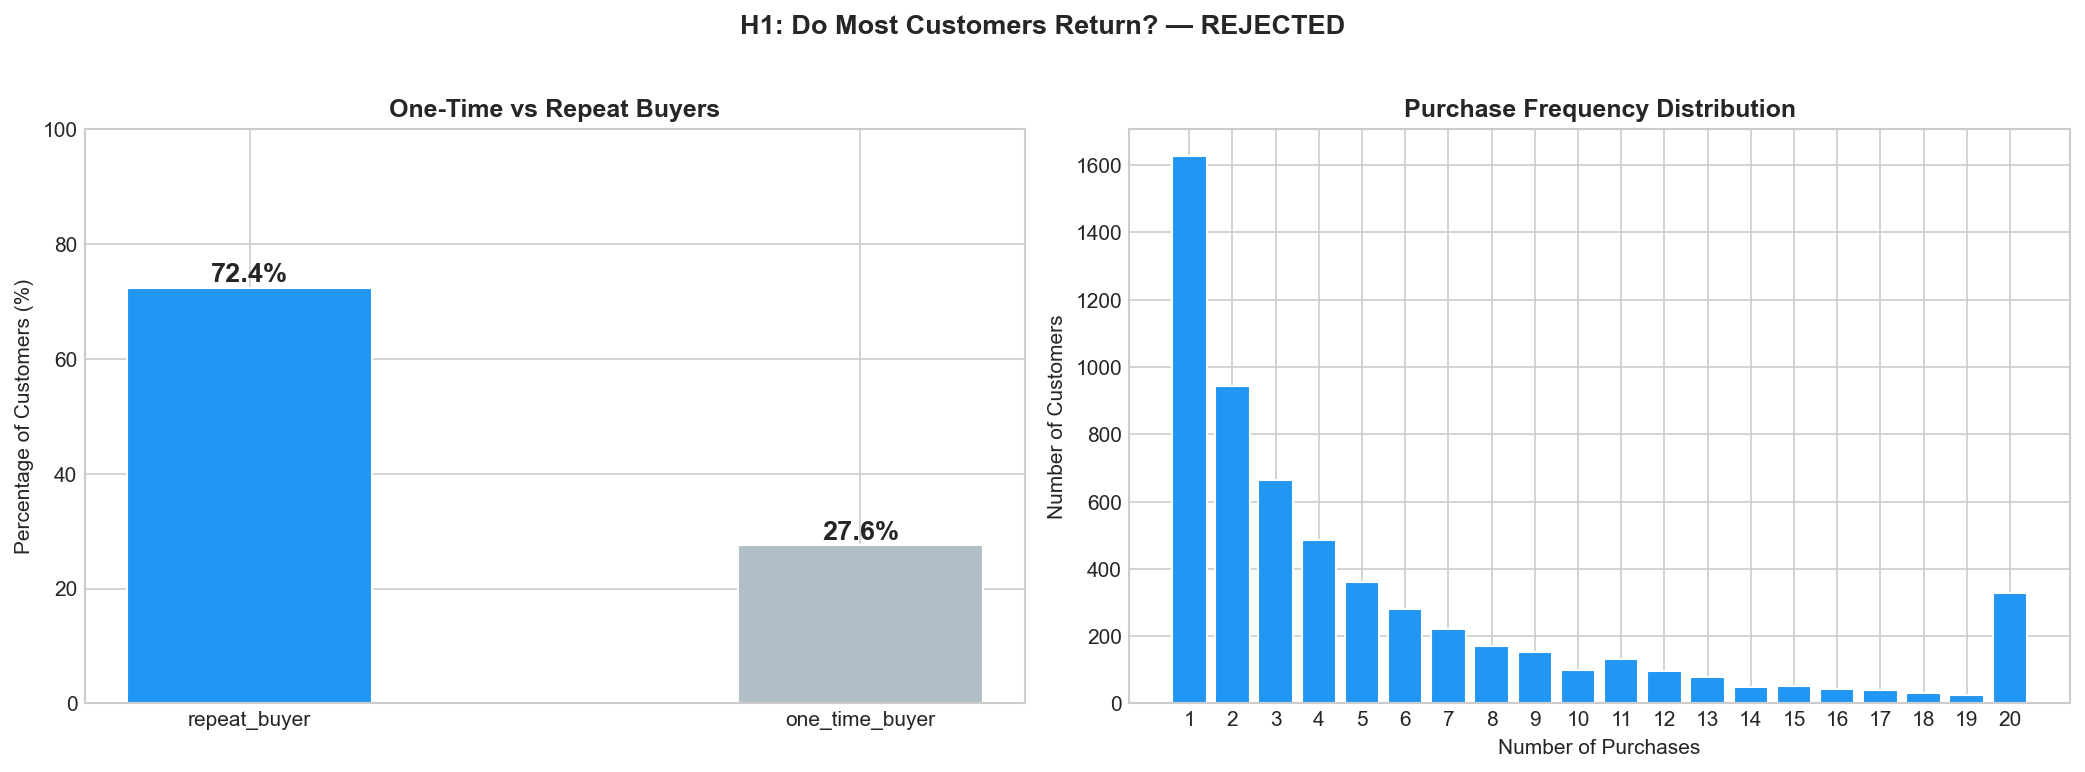

In [13]:
# HYPOTHESIS 1
# Most customers do not return after their first purchase

print("HYPOTHESIS 1: Do Most Customers Return?")
print("=" * 20)

# counting the invoices per customer
purchase_counts = purchases.groupby('Customer ID')['Invoice'].nunique()\
    .reset_index().rename(columns = {'Invoice' : 'total_purchases'})

# label repeat and one-time buyers
purchase_counts['buyer_type'] = purchase_counts['total_purchases']\
    .apply(lambda x: 'one_time_buyer' if x == 1  else 'repeat_buyer')

# summarize
summary = purchase_counts['buyer_type'].value_counts().reset_index()
summary.columns = ['buyer_type', 'count']
summary['percentage'] = (
    summary['count']/len(purchase_counts) * 100
).round(1)

# VISUALIZING THE RESULT

print('\n=== One-Time vs Repeat Buyers ===')
print(summary.to_string(index = False))

# purchase frequency distribution
freq_dist = purchase_counts['total_purchases'].clip(upper = 20)\
    .value_counts().sort_index()

# visualize
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# bar chart
colors = [
    '#2196F3' if bt == 'repeat_buyer' else '#B0BEC5' for bt in summary['buyer_type']
]
bars = axes[0].bar(
    summary['buyer_type'],
    summary['percentage'],
    color = colors,
    edgecolor = 'white',
    width = 0.4
)
axes[0].set_title(
    'One-Time vs Repeat Buyers',
    fontweight='bold', fontsize=12
)
axes[0].set_ylabel('Percentage of Customers (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, summary['percentage']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val}%',
        ha='center', fontweight='bold', fontsize=13
    )

# Frequency distribution
axes[1].bar(
    freq_dist.index,
    freq_dist.values,
    color='#2196F3',
    edgecolor='white'
)
axes[1].set_title(
    'Purchase Frequency Distribution',
    fontweight='bold', fontsize=12
)
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(range(1, 21))

# Confirmation check
one_time_pct = summary[
    summary['buyer_type'] == 'one_time_buyer'
]['percentage'].values[0]

result = 'CONFIRMED' if one_time_pct > 50 else 'REJECTED'
print(f"\nOne-time buyers: {one_time_pct}%")
print(f"Hypothesis 1: {result}")

plt.suptitle(
    f'H1: Do Most Customers Return? — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_1_repeat_buyers.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


HYPOTHESIS 2: Do Returning Customers Return Quickly?

=== Days to Second Purchase ===
Median: 55 days
Mean:   97 days
Min:    0 days
Max:    714 days

=== Return Speed Breakdown ===
         return_speed  count  percentage
 90+ days (very slow)   1506        35.4
    0-30 days (quick)   1393        32.7
31-60 days (moderate)    854        20.1
    61-90 days (slow)    502        11.8



Median days to return: 55
Hypothesis 2: REJECTED


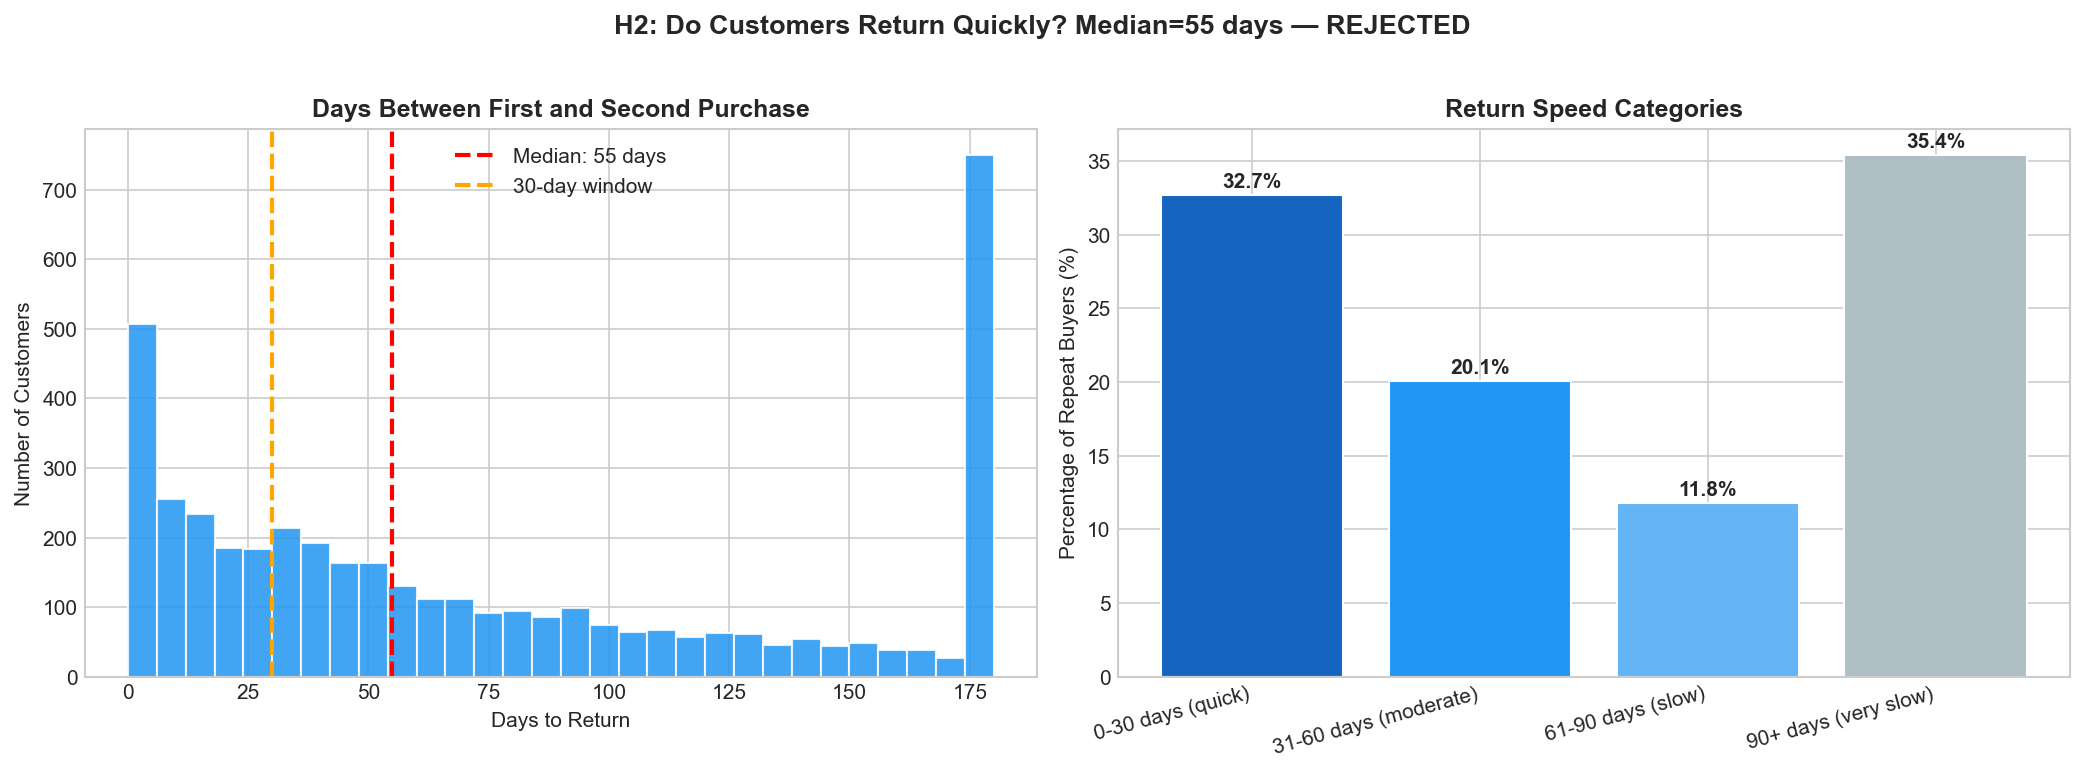

In [16]:
#  HYPOTHESIS 2
# Users that return, return quickly

print("HYPOTHESIS 2: Do Returning Customers Return Quickly?")
print("=" * 20)

purchases['InvoiceDate'] = pd.to_datetime(purchases['InvoiceDate'])

# Get repeat buyers only
repeat_buyers = purchase_counts[
    purchase_counts['total_purchases'] >= 2
]['Customer ID'].values

repeat_purchases = purchases[
    purchases['Customer ID'].isin(repeat_buyers)
].copy()

# Get first and second purchase per customer
first_purchase = repeat_purchases[
    repeat_purchases['purchase_rank'] == 1
][['Customer ID', 'InvoiceDate']]\
    .rename(columns={'InvoiceDate': 'first_purchase_date'})

second_purchase = repeat_purchases[
    repeat_purchases['purchase_rank'] == 2
][['Customer ID', 'InvoiceDate']]\
    .rename(columns={'InvoiceDate': 'second_purchase_date'})

# Merge and calculate days between
first_to_second = first_purchase.merge(
    second_purchase, on='Customer ID'
)
first_to_second['days_to_return'] = (
    first_to_second['second_purchase_date'] - first_to_second['first_purchase_date']
).dt.days

# Label return speed
def label_return_speed(days):
    if days <= 30:
        return '0-30 days (quick)'
    elif days <= 60:
        return '31-60 days (moderate)'
    elif days <= 90:
        return '61-90 days (slow)'
    else:
        return '90+ days (very slow)'

first_to_second['return_speed'] = first_to_second[
    'days_to_return'
].apply(label_return_speed)

# Summary statistics
median_days = first_to_second['days_to_return'].median()
mean_days = first_to_second['days_to_return'].mean()

print(f"\n=== Days to Second Purchase ===")
print(f"Median: {median_days:.0f} days")
print(f"Mean:   {mean_days:.0f} days")
print(f"Min:    {first_to_second['days_to_return'].min():.0f} days")
print(f"Max:    {first_to_second['days_to_return'].max():.0f} days")

speed_summary = first_to_second['return_speed']\
    .value_counts()\
    .reset_index()
speed_summary.columns = ['return_speed', 'count']
speed_summary['percentage'] = (
    speed_summary['count'] /
    len(first_to_second) * 100
).round(1)

print(f"\n=== Return Speed Breakdown ===")
print(speed_summary.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution histogram
axes[0].hist(
    first_to_second['days_to_return'].clip(upper=180),
    bins=30,
    color='#2196F3',
    edgecolor='white',
    alpha=0.85
)
axes[0].axvline(
    median_days,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_days:.0f} days'
)
axes[0].axvline(
    30,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='30-day window'
)
axes[0].set_title(
    'Days Between First and Second Purchase',
    fontweight='bold'
)
axes[0].set_xlabel('Days to Return')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Speed categories
speed_order = [
    '0-30 days (quick)',
    '31-60 days (moderate)',
    '61-90 days (slow)',
    '90+ days (very slow)'
]
speed_plot = speed_summary.set_index('return_speed')\
    .reindex(speed_order)['percentage']

axes[1].bar(
    range(len(speed_order)),
    speed_plot.values,
    color=['#1565C0', '#2196F3', '#64B5F6', '#B0BEC5'],
    edgecolor='white'
)
axes[1].set_xticks(range(len(speed_order)))
axes[1].set_xticklabels(speed_order, rotation=15, ha='right')
axes[1].set_title('Return Speed Categories', fontweight='bold')
axes[1].set_ylabel('Percentage of Repeat Buyers (%)')
for i, val in enumerate(speed_plot.values):
    if not np.isnan(val):
        axes[1].text(
            i, val + 0.5, f'{val}%',
            ha='center', fontweight='bold'
        )

result = 'CONFIRMED' if median_days <= 30 else 'REJECTED'
print(f"\nMedian days to return: {median_days:.0f}")
print(f"Hypothesis 2: {result}")

plt.suptitle(
    f'H2: Do Customers Return Quickly? '
    f'Median={median_days:.0f} days — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_2_return_speed.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


HYPOTHESIS 3: Where Is the Largest Drop-off?

=== Customers at Each Purchase Number ===
 purchase_rank  customer_count
             1            5881
             2            4258
             3            3314
             4            2652
             5            2166
             6            1802
             7            1522
             8            1303
             9            1130
            10             975

=== Drop-off Table (Sorted by Severity) ===
     transition  customer_count  dropoff_pct
 Purchase 1 → 2            4258         27.6
 Purchase 2 → 3            3314         22.2
 Purchase 3 → 4            2652         20.0
 Purchase 4 → 5            2166         18.3
 Purchase 5 → 6            1802         16.8
 Purchase 6 → 7            1522         15.5
 Purchase 7 → 8            1303         14.4
Purchase 9 → 10             975         13.7
 Purchase 8 → 9            1130         13.3

Largest drop-off: Purchase 1 → 2
Hypothesis 3: CONFIRMED


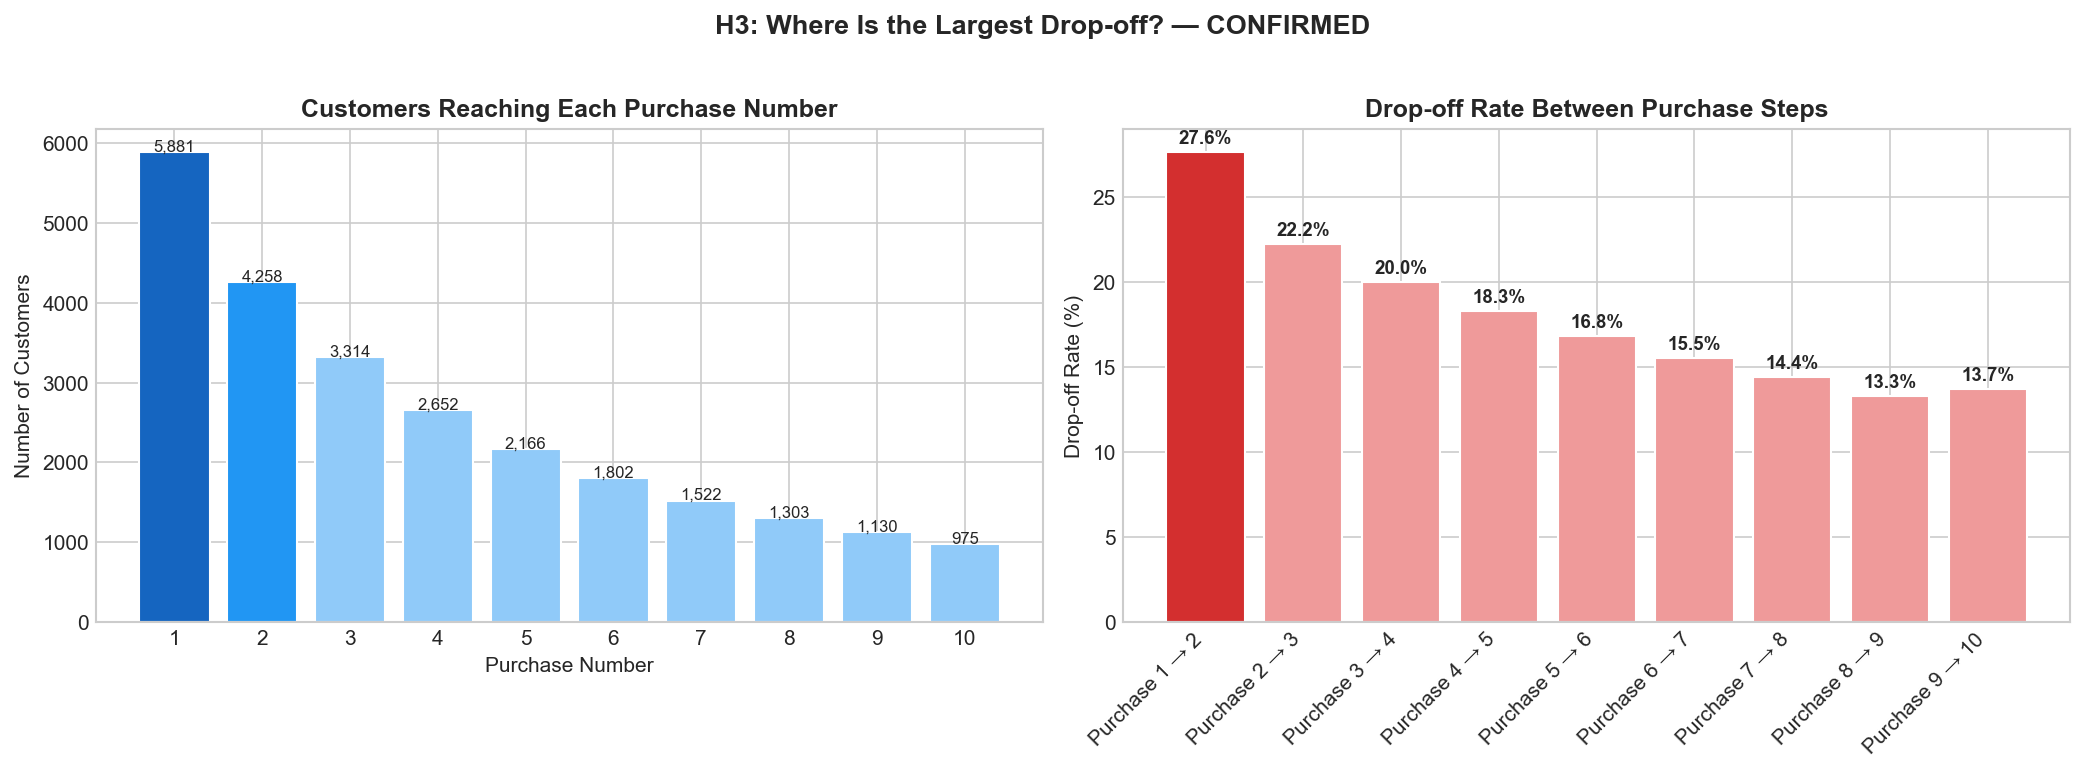

In [17]:
# HYPOTHESIS 3
# Largest drop-off happens immediately after the first purchase

print("HYPOTHESIS 3: Where Is the Largest Drop-off?")
print("=" * 20)

# Count customers who reached each purchase rank
max_rank = 10
rank_counts = purchases[
    purchases['purchase_rank'] <= max_rank
].groupby('purchase_rank')['Customer ID']\
    .nunique()\
    .reset_index()
rank_counts.columns = ['purchase_rank', 'customer_count']

# Calculate drop-off between consecutive ranks
rank_counts['previous_count'] = rank_counts[
    'customer_count'
].shift(1)

rank_counts['dropoff_pct'] = (
    (rank_counts['previous_count'] -
     rank_counts['customer_count']) /
    rank_counts['previous_count'] * 100
).round(1)

rank_counts['transition'] = rank_counts[
    'purchase_rank'
].apply(
    lambda x: f'Purchase {x-1} → {x}' if x > 1
    else 'Starting Point'
)

dropoff_table = rank_counts.dropna(
    subset=['dropoff_pct']
).sort_values('dropoff_pct', ascending=False)

print("\n=== Customers at Each Purchase Number ===")
print(rank_counts[[
    'purchase_rank', 'customer_count'
]].to_string(index=False))

print("\n=== Drop-off Table (Sorted by Severity) ===")
print(dropoff_table[[
    'transition', 'customer_count', 'dropoff_pct'
]].to_string(index=False))

# Confirmation check
top_dropoff = dropoff_table.iloc[0]['transition']
result = ('CONFIRMED'
          if top_dropoff == 'Purchase 1 → 2'
          else 'REJECTED')
print(f"\nLargest drop-off: {top_dropoff}")
print(f"Hypothesis 3: {result}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count per rank
axes[0].bar(
    rank_counts['purchase_rank'],
    rank_counts['customer_count'],
    color=[
        '#1565C0' if r == 1 else
        '#2196F3' if r == 2 else
        '#90CAF9'
        for r in rank_counts['purchase_rank']
    ],
    edgecolor='white'
)
axes[0].set_title(
    'Customers Reaching Each Purchase Number',
    fontweight='bold'
)
axes[0].set_xlabel('Purchase Number')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticks(rank_counts['purchase_rank'])
for _, row in rank_counts.iterrows():
    axes[0].text(
        row['purchase_rank'],
        row['customer_count'] + 15,
        f"{int(row['customer_count']):,}",
        ha='center', fontsize=8
    )

# Drop-off percentage
dropoff_plot = rank_counts.dropna(subset=['dropoff_pct'])
bar_colors = [
    '#D32F2F' if t == 'Purchase 1 → 2' else '#EF9A9A'
    for t in dropoff_plot['transition']
]
axes[1].bar(
    range(len(dropoff_plot)),
    dropoff_plot['dropoff_pct'],
    color=bar_colors,
    edgecolor='white'
)
axes[1].set_xticks(range(len(dropoff_plot)))
axes[1].set_xticklabels(
    dropoff_plot['transition'],
    rotation=45, ha='right'
)
axes[1].set_title(
    'Drop-off Rate Between Purchase Steps',
    fontweight='bold'
)
axes[1].set_ylabel('Drop-off Rate (%)')
for i, val in enumerate(dropoff_plot['dropoff_pct']):
    axes[1].text(
        i, val + 0.5, f'{val}%',
        ha='center', fontweight='bold', fontsize=9
    )

plt.suptitle(
    f'H3: Where Is the Largest Drop-off? — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_3_dropoff.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


HYPOTHESIS 4: First Session Behavior Differences

=== First Session Behavior: One-Time vs Repeat Buyers ===
buyer_type              one_time_buyer  repeat_buyer
customer_count                 1626.00       4255.00
median_items                    132.00        166.00
median_unique_products           16.00         19.00
median_revenue                  231.92        307.44
median_avg_price                  2.94          2.92

Repeat buyers higher on 3/3 metrics
Hypothesis 4: CONFIRMED


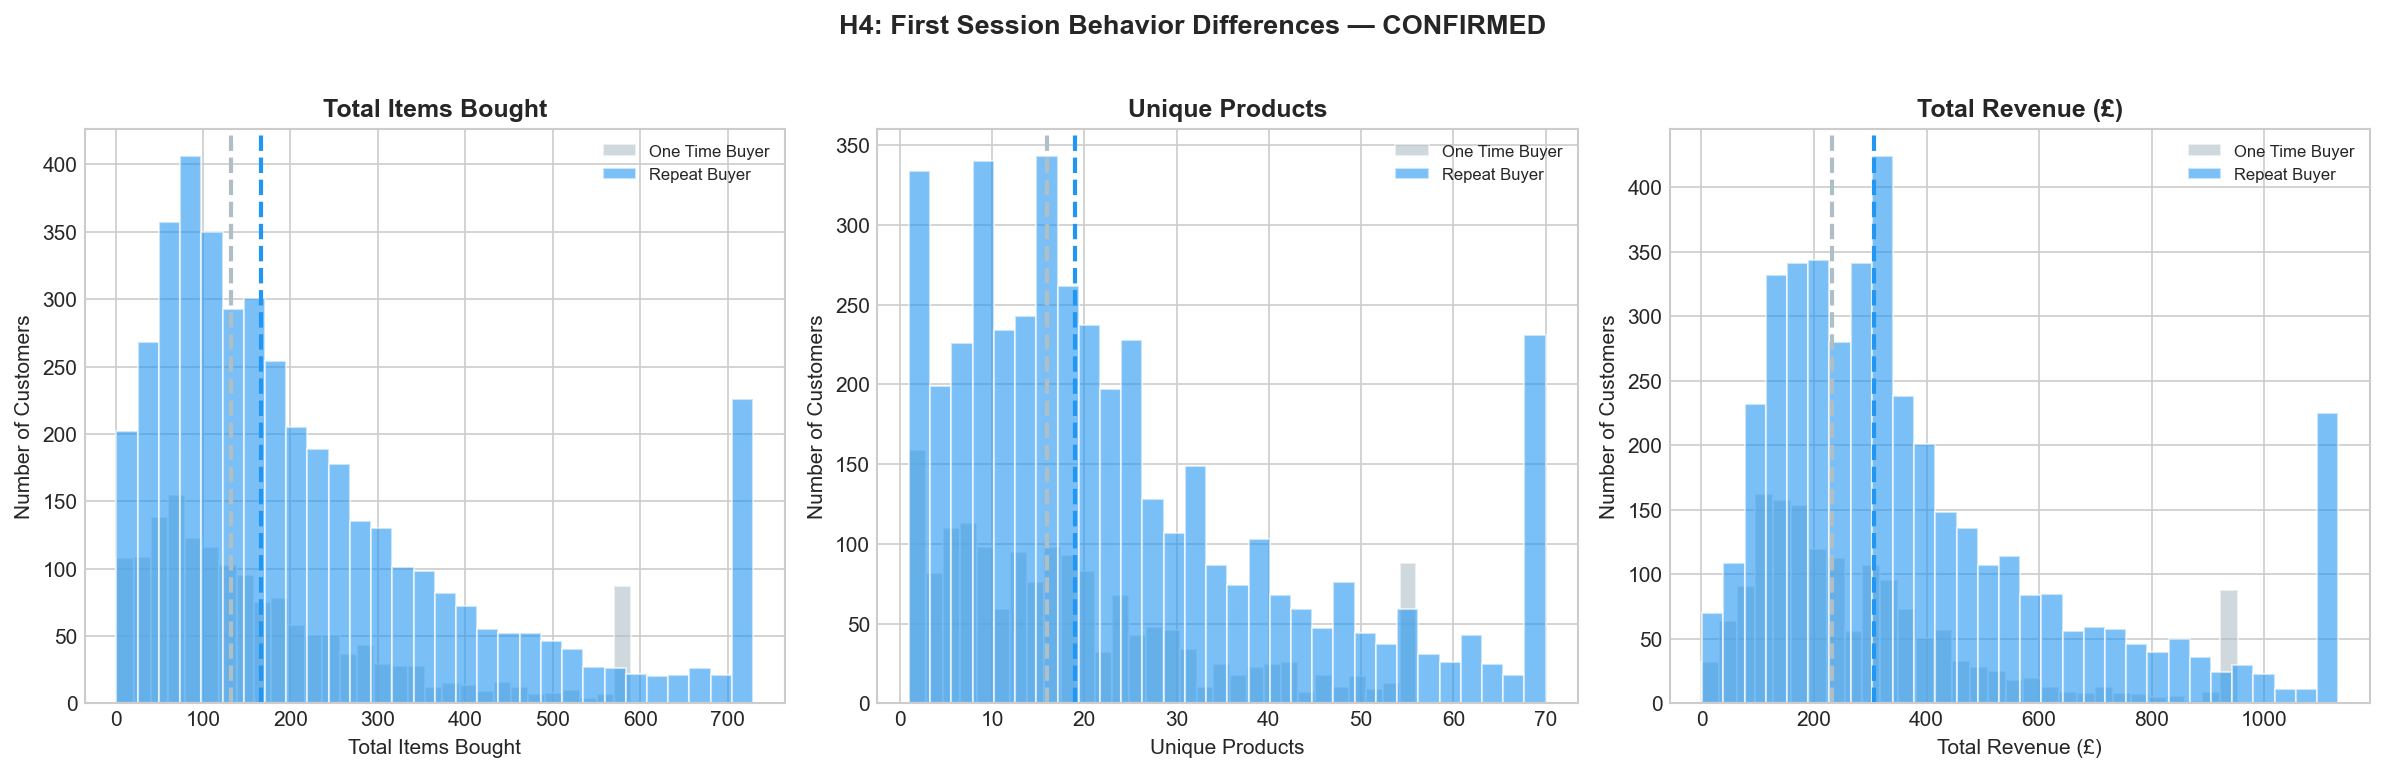

In [18]:
#  HYPOTHESIS 4
# One-time buyers behave differently from repeat buyers

print("HYPOTHESIS 4: First Session Behavior Differences")
print("=" * 20)

# Get each customer's first invoice only
first_invoices = purchases[
    purchases['purchase_rank'] == 1
][['Customer ID', 'Invoice']].drop_duplicates()

# Get all line items from those first invoices
first_session_items = df[
    df['Invoice'].isin(first_invoices['Invoice'])
].merge(first_invoices, on=['Customer ID', 'Invoice'])

# Aggregate first session behavior per customer
first_session = first_session_items.groupby(
    'Customer ID'
).agg(
    total_items_bought=('Quantity', 'sum'),
    unique_products=('StockCode', 'nunique'),
    total_revenue=('Revenue', 'sum'),
    avg_item_price=('Price', 'mean')
).reset_index()

# Add buyer type label
first_session = first_session.merge(
    purchase_counts[['Customer ID', 'buyer_type']],
    on='Customer ID'
)

# Compare groups using median
comparison = first_session.groupby('buyer_type').agg(
    customer_count=('Customer ID', 'count'),
    median_items=('total_items_bought', 'median'),
    median_unique_products=('unique_products', 'median'),
    median_revenue=('total_revenue', 'median'),
    median_avg_price=('avg_item_price', 'median')
).round(2)

print("\n=== First Session Behavior: One-Time vs Repeat Buyers ===")
print(comparison.T)

# Confirmation: repeat buyers higher on 2+ of 3 metrics
repeat = comparison.loc['repeat_buyer']
one_time = comparison.loc['one_time_buyer']

metrics_higher = sum([
    repeat['median_items'] > one_time['median_items'],
    repeat['median_unique_products'] > one_time['median_unique_products'],
    repeat['median_revenue'] > one_time['median_revenue']
])

result = 'CONFIRMED' if metrics_higher >= 2 else 'REJECTED'
print(f"\nRepeat buyers higher on {metrics_higher}/3 metrics")
print(f"Hypothesis 4: {result}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('total_items_bought', 'Total Items Bought'),
    ('unique_products', 'Unique Products'),
    ('total_revenue', 'Total Revenue (£)')
]

colors = {
    'one_time_buyer': '#B0BEC5',
    'repeat_buyer': '#2196F3'
}

for ax, (metric, label) in zip(axes, metrics):
    for buyer_type in ['one_time_buyer', 'repeat_buyer']:
        data = first_session[
            first_session['buyer_type'] == buyer_type
        ][metric]
        ax.hist(
            data.clip(upper=data.quantile(0.95)),
            bins=30,
            alpha=0.6,
            label=buyer_type.replace('_', ' ').title(),
            color=colors[buyer_type],
            edgecolor='white'
        )
        ax.axvline(
            data.median(),
            color=colors[buyer_type],
            linestyle='--',
            linewidth=2
        )
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Customers')
    ax.legend(fontsize=8)

plt.suptitle(
    f'H4: First Session Behavior Differences — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_4_buyer_behavior.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


HYPOTHESIS 5: Does the Second Purchase Drive Loyalty?

=== Conversion and Drop-off Rates ===
    transition  customer_count  conversion_rate  dropoff_rate
Purchase 1 → 2            4258             72.4          27.6
Purchase 2 → 3            3314             77.8          22.2

=== Hypothesis Test ===
Drop-off after 1st purchase: 27.6%
Drop-off after 2nd purchase: 22.2%
Ratio: 1.24× (threshold: 2.0)
Hypothesis 5: REJECTED


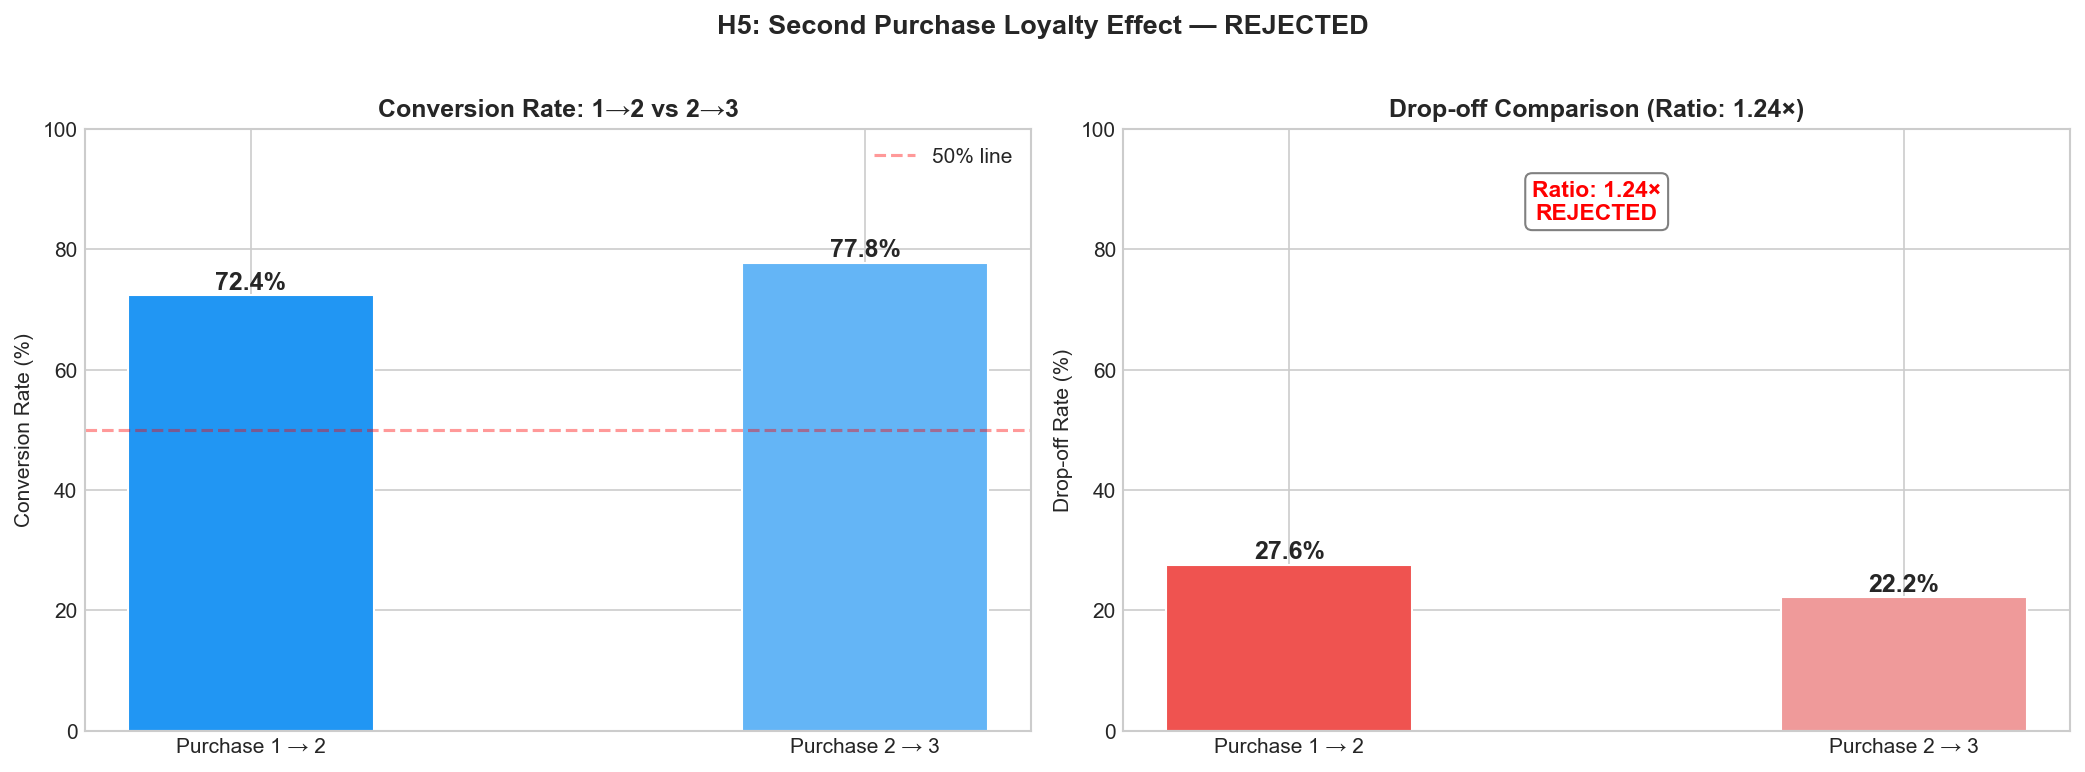

In [19]:
# HYPOTHESIS 5
# Second purchasers are significantly more likely to keep buying than first purchasers

print("HYPOTHESIS 5: Does the Second Purchase Drive Loyalty?")
print("=" * 20)

# Reuse rank_counts from H3 — focus on ranks 1, 2, 3
h5_counts = rank_counts[
    rank_counts['purchase_rank'] <= 3
][['purchase_rank', 'customer_count']].copy()

# Conversion and drop-off rates
h5_counts['conversion_rate'] = (
    h5_counts['customer_count'] /
    h5_counts['customer_count'].shift(1) * 100
).round(1)

h5_counts['dropoff_rate'] = (
    100 - h5_counts['conversion_rate']
).round(1)

h5_counts['transition'] = h5_counts['purchase_rank'].apply(
    lambda x: f'Purchase {x-1} → {x}'
    if x > 1 else 'Starting Point'
)

transitions = h5_counts[h5_counts['purchase_rank'] > 1]

print("\n=== Conversion and Drop-off Rates ===")
print(transitions[[
    'transition', 'customer_count',
    'conversion_rate', 'dropoff_rate'
]].to_string(index=False))

# Calculate ratio
dropoff_1_to_2 = h5_counts[
    h5_counts['purchase_rank'] == 2
]['dropoff_rate'].values[0]

dropoff_2_to_3 = h5_counts[
    h5_counts['purchase_rank'] == 3
]['dropoff_rate'].values[0]

ratio = round(dropoff_1_to_2 / dropoff_2_to_3, 2)

print(f"\n=== Hypothesis Test ===")
print(f"Drop-off after 1st purchase: {dropoff_1_to_2}%")
print(f"Drop-off after 2nd purchase: {dropoff_2_to_3}%")
print(f"Ratio: {ratio}× (threshold: 2.0)")

result = 'CONFIRMED' if ratio >= 2.0 else 'REJECTED'
print(f"Hypothesis 5: {result}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conversion rates
bars1 = axes[0].bar(
    transitions['transition'],
    transitions['conversion_rate'],
    color=['#2196F3', '#64B5F6'],
    edgecolor='white',
    width=0.4
)
axes[0].set_title(
    'Conversion Rate: 1→2 vs 2→3',
    fontweight='bold'
)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].axhline(
    50, color='red', linestyle='--',
    alpha=0.4, label='50% line'
)
axes[0].legend()
for bar, val in zip(
    bars1, transitions['conversion_rate']
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val}%',
        ha='center', fontweight='bold', fontsize=12
    )

# Drop-off rates
bars2 = axes[1].bar(
    transitions['transition'],
    transitions['dropoff_rate'],
    color=['#EF5350', '#EF9A9A'],
    edgecolor='white',
    width=0.4
)
axes[1].set_title(
    f'Drop-off Comparison (Ratio: {ratio}×)',
    fontweight='bold'
)
axes[1].set_ylabel('Drop-off Rate (%)')
axes[1].set_ylim(0, 100)
for bar, val in zip(
    bars2, transitions['dropoff_rate']
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val}%',
        ha='center', fontweight='bold', fontsize=12
    )

axes[1].annotate(
    f'Ratio: {ratio}×\n{result}',
    xy=(0.5, 0.85),
    xycoords='axes fraction',
    ha='center', fontsize=11, fontweight='bold',
    color='green' if ratio >= 2.0 else 'red',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='grey'
    )
)

plt.suptitle(
    f'H5: Second Purchase Loyalty Effect — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_5_second_purchase_loyalty.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


HYPOTHESIS 6: Do Returns Correlate with Lower Retention?



=== Analysis A: Returners vs Non-Returners ===
returner_status  customer_count  retained_count  retention_rate
   non_returner            3370            1966            58.3
       returner            2511            2289            91.2

=== Analysis B: Dose-Response ===
return_segment  customer_count  retention_rate
      1 return             637            85.7
     2 returns             440            86.4
     3 returns             290            91.0
    4+ returns            1144            96.1

Binary confirmed: False
Dose-response downtrend: False
Hypothesis 6: REJECTED


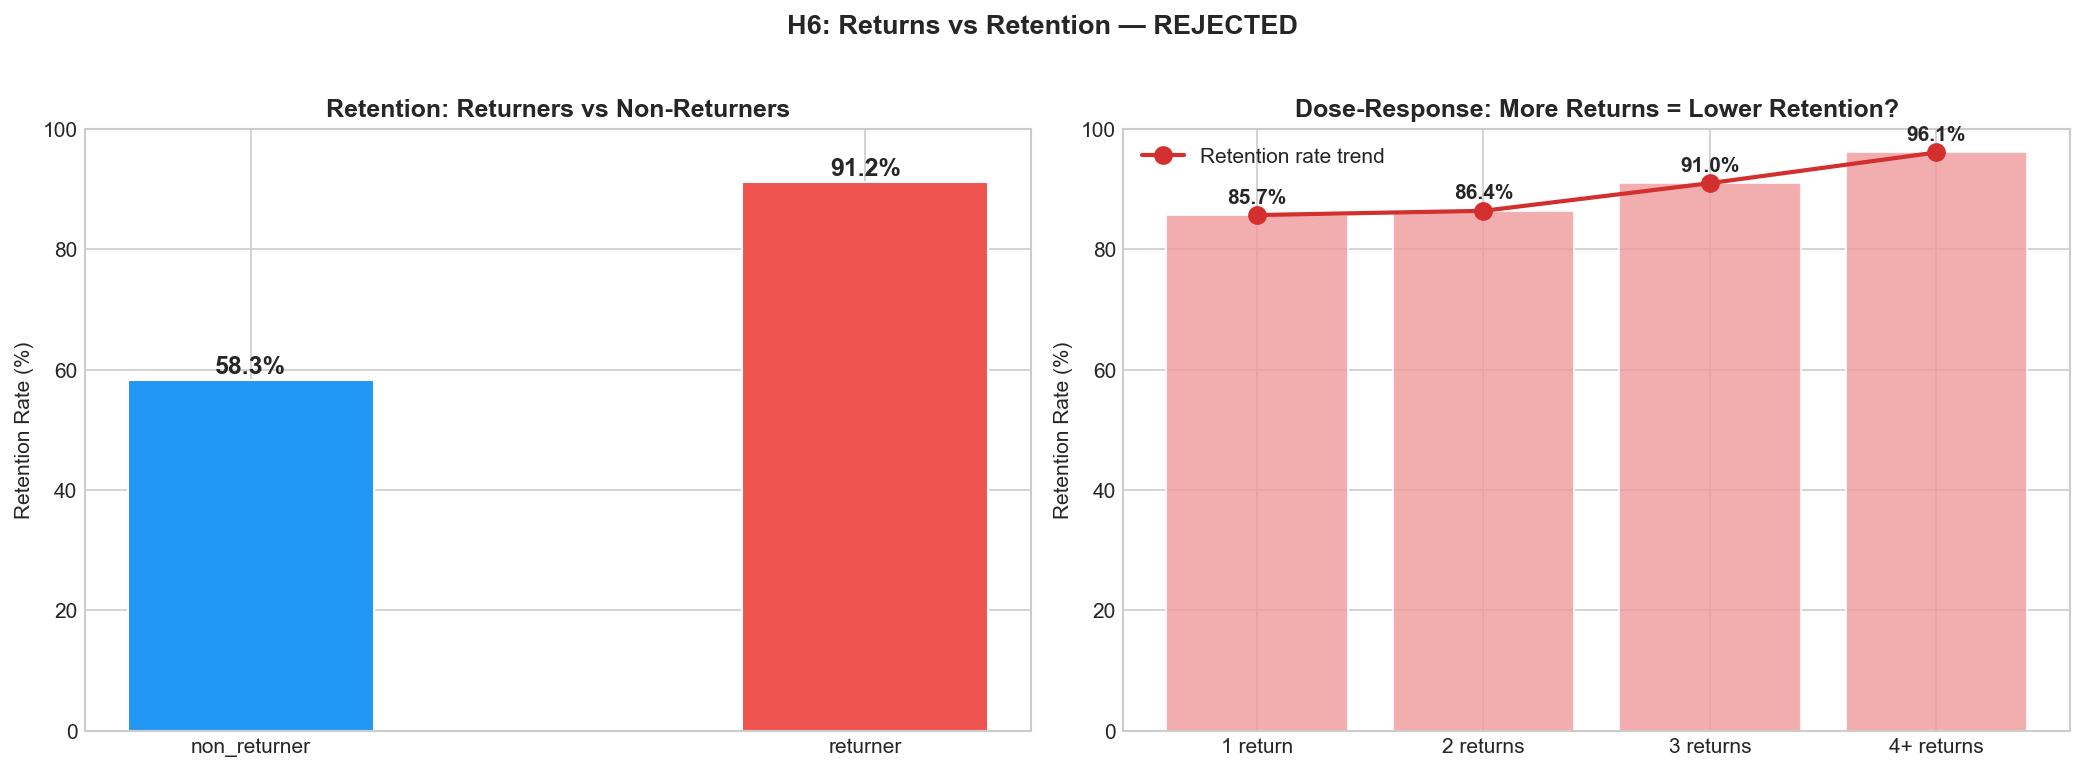

In [25]:
# HYPOTHESIS 6
# Returns and cancellations correlate with lower retention

print("HYPOTHESIS 6: Do Returns Correlate with Lower Retention?")
print("=" * 20)

# Get returns and cancellations from raw_df
# (removed during cleaning but needed here)
# LOAD RAW DATA
raw_df = pd.read_csv('../data/raw/online_retail_II.csv')
returns_raw = raw_df[raw_df['Customer ID'].notna()].copy()
returns_raw['Customer ID'] = returns_raw[
    'Customer ID'
].astype(int)

returns_only = returns_raw[
    (returns_raw['Quantity'] < 0) |
    (returns_raw['Invoice'].astype(str).str.startswith('C'))
].copy()

# Count returns per customer
return_counts = returns_only\
    .groupby('Customer ID')\
    .size()\
    .reset_index()\
    .rename(columns={0: 'return_count'})

# Merge with customer profiles
# is_retained = made 2+ purchases
all_customers = purchase_counts[
    ['Customer ID', 'total_purchases']
].copy()
all_customers['is_retained'] = (
    all_customers['total_purchases'] >= 2
).astype(int)

all_customers = all_customers.merge(
    return_counts, on='Customer ID', how='left'
)
all_customers['return_count'] = all_customers[
    'return_count'
].fillna(0).astype(int)

all_customers['returner_status'] = all_customers[
    'return_count'
].apply(
    lambda x: 'returner' if x > 0 else 'non_returner'
)

# ---- ANALYSIS A: Binary comparison ----
binary = all_customers.groupby('returner_status').agg(
    customer_count=('Customer ID', 'count'),
    retained_count=('is_retained', 'sum')
).reset_index()
binary['retention_rate'] = (
    binary['retained_count'] /
    binary['customer_count'] * 100
).round(1)

print("\n=== Analysis A: Returners vs Non-Returners ===")
print(binary[[
    'returner_status', 'customer_count',
    'retained_count', 'retention_rate'
]].to_string(index=False))

# ---- ANALYSIS B: Dose-response ----
returners_only = all_customers[
    all_customers['returner_status'] == 'returner'
].copy()

def return_segment(n):
    if n == 1:
        return '1 return'
    elif n == 2:
        return '2 returns'
    elif n == 3:
        return '3 returns'
    else:
        return '4+ returns'

returners_only['return_segment'] = returners_only[
    'return_count'
].apply(return_segment)

dose = returners_only.groupby('return_segment').agg(
    customer_count=('Customer ID', 'count'),
    retention_rate=('is_retained', 'mean')
).reset_index()
dose['retention_rate'] = (
    dose['retention_rate'] * 100
).round(1)

segment_order = [
    '1 return', '2 returns',
    '3 returns', '4+ returns'
]
dose['return_segment'] = pd.Categorical(
    dose['return_segment'],
    categories=segment_order,
    ordered=True
)
dose = dose.sort_values('return_segment')

print("\n=== Analysis B: Dose-Response ===")
print(dose.to_string(index=False))

# Confirmation: downtrend in retention as returns increase
retention_vals = dose['retention_rate'].values
is_downtrend = all(
    retention_vals[i] >= retention_vals[i+1]
    for i in range(len(retention_vals)-1)
)

# Binary: returners should have lower retention
returner_rate = binary[
    binary['returner_status'] == 'returner'
]['retention_rate'].values[0]
non_returner_rate = binary[
    binary['returner_status'] == 'non_returner'
]['retention_rate'].values[0]

binary_confirmed = returner_rate < non_returner_rate

result = (
    'CONFIRMED'
    if binary_confirmed and is_downtrend
    else 'PARTIALLY CONFIRMED'
    if binary_confirmed or is_downtrend
    else 'REJECTED'
)
print(f"\nBinary confirmed: {binary_confirmed}")
print(f"Dose-response downtrend: {is_downtrend}")
print(f"Hypothesis 6: {result}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Analysis A
colors_a = [
    '#EF5350' if s == 'returner' else '#2196F3'
    for s in binary['returner_status']
]
bars_a = axes[0].bar(
    binary['returner_status'],
    binary['retention_rate'],
    color=colors_a,
    edgecolor='white',
    width=0.4
)
axes[0].set_title(
    'Retention: Returners vs Non-Returners',
    fontweight='bold'
)
axes[0].set_ylabel('Retention Rate (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars_a, binary['retention_rate']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val}%',
        ha='center', fontweight='bold', fontsize=12
    )

# Analysis B
axes[1].bar(
    dose['return_segment'],
    dose['retention_rate'],
    color='#EF9A9A',
    edgecolor='white',
    alpha=0.8
)
axes[1].plot(
    dose['return_segment'],
    dose['retention_rate'],
    color='#D32F2F',
    marker='o',
    linewidth=2,
    markersize=8,
    label='Retention rate trend'
)
axes[1].set_title(
    'Dose-Response: More Returns = Lower Retention?',
    fontweight='bold'
)
axes[1].set_ylabel('Retention Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()
for i, row in dose.reset_index().iterrows():
    axes[1].text(
        i,
        row['retention_rate'] + 2,
        f"{row['retention_rate']}%",
        ha='center', fontweight='bold', fontsize=10
    )

plt.suptitle(
    f'H6: Returns vs Retention — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_6_returns_retention.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

HYPOTHESIS 7: Does Retention Vary by Country?
Countries with 50+ customers: 3
Countries excluded (too small): 38
Excluded: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'Greece', 'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'Unspecified', 'West Indies']

=== Retention by Country (50+ customers) ===
primary_country  customer_count  retained_count  retention_rate
        Germany             106              84            79.2
 United Kingdom            5353            3876            72.4
         France              95              68            71.6

=== Hypothesis Test ===
Best:  Germany — 79.2%
Worst: France — 71.6%
Range: 7.6 pp (threshold: 20pp)
Hypothesis 7: R

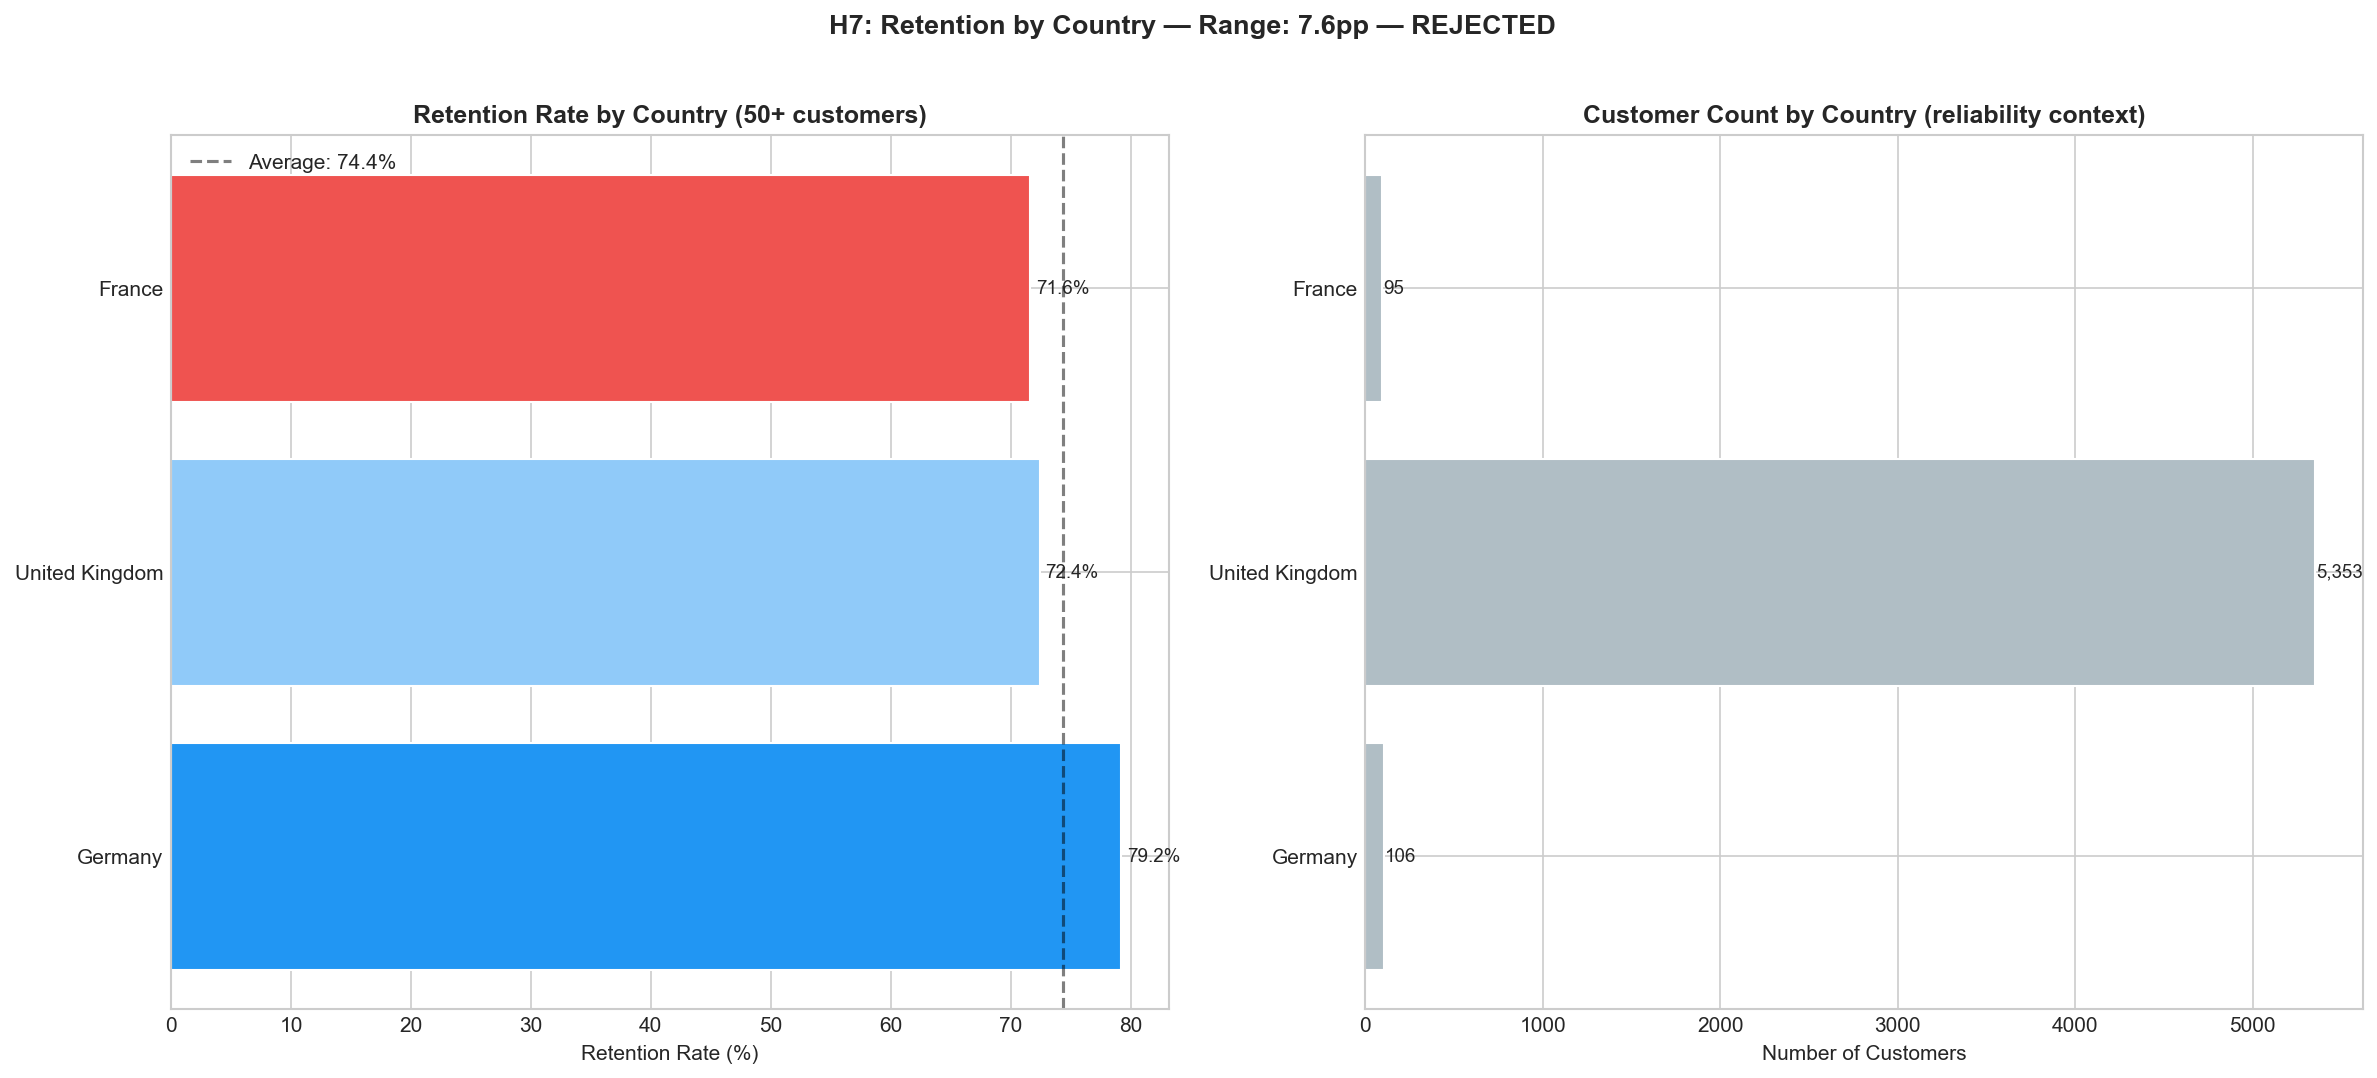

In [22]:
# HYPOTHESIS 7
# Retention varies significantly by country

print("HYPOTHESIS 7: Does Retention Vary by Country?")
print("=" * 20)

# Get each customer's primary country
customer_country = df.groupby('Customer ID')['Country']\
    .agg(lambda x: x.value_counts().index[0])\
    .reset_index()\
    .rename(columns={'Country': 'primary_country'})

# Add country to customer profiles
country_analysis = all_customers.merge(
    customer_country, on='Customer ID', how='left'
)

# Retention rate per country
country_retention = country_analysis.groupby(
    'primary_country'
).agg(
    customer_count=('Customer ID', 'count'),
    retained_count=('is_retained', 'sum')
).reset_index()

country_retention['retention_rate'] = (
    country_retention['retained_count'] /
    country_retention['customer_count'] * 100
).round(1)

# Apply minimum sample size filter (50+ customers)
MIN_CUSTOMERS = 50
country_sufficient = country_retention[
    country_retention['customer_count'] >= MIN_CUSTOMERS
].copy().sort_values('retention_rate', ascending=False)

country_small = country_retention[
    country_retention['customer_count'] < MIN_CUSTOMERS
]

print(f"Countries with 50+ customers: "
      f"{len(country_sufficient)}")
print(f"Countries excluded (too small): "
      f"{len(country_small)}")
print(f"Excluded: {country_small['primary_country'].tolist()}")

print(f"\n=== Retention by Country (50+ customers) ===")
print(country_sufficient[[
    'primary_country', 'customer_count',
    'retained_count', 'retention_rate'
]].to_string(index=False))

# Hypothesis test
retention_range = (
    country_sufficient['retention_rate'].max() -
    country_sufficient['retention_rate'].min()
)
best = country_sufficient.iloc[0]
worst = country_sufficient.iloc[-1]

print(f"\n=== Hypothesis Test ===")
print(f"Best:  {best['primary_country']} — "
      f"{best['retention_rate']}%")
print(f"Worst: {worst['primary_country']} — "
      f"{worst['retention_rate']}%")
print(f"Range: {retention_range:.1f} pp (threshold: 20pp)")

result = (
    'CONFIRMED' if retention_range >= 20
    else 'REJECTED'
)
print(f"Hypothesis 7: {result}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Retention rate per country
bar_colors = [
    '#2196F3' if r == country_sufficient[
        'retention_rate'
    ].max()
    else '#EF5350' if r == country_sufficient[
        'retention_rate'
    ].min()
    else '#90CAF9'
    for r in country_sufficient['retention_rate']
]

axes[0].barh(
    country_sufficient['primary_country'],
    country_sufficient['retention_rate'],
    color=bar_colors,
    edgecolor='white'
)
axes[0].axvline(
    country_sufficient['retention_rate'].mean(),
    color='black', linestyle='--', alpha=0.5,
    label=f"Average: "
          f"{country_sufficient['retention_rate'].mean():.1f}%"
)
axes[0].set_title(
    'Retention Rate by Country (50+ customers)',
    fontweight='bold'
)
axes[0].set_xlabel('Retention Rate (%)')
axes[0].legend()
for i, row in country_sufficient.reset_index().iterrows():
    axes[0].text(
        row['retention_rate'] + 0.5,
        i,
        f"{row['retention_rate']}%",
        va='center', fontsize=9
    )

# Customer count context
axes[1].barh(
    country_sufficient['primary_country'],
    country_sufficient['customer_count'],
    color='#B0BEC5',
    edgecolor='white'
)
axes[1].set_title(
    'Customer Count by Country (reliability context)',
    fontweight='bold'
)
axes[1].set_xlabel('Number of Customers')
for i, row in country_sufficient.reset_index().iterrows():
    axes[1].text(
        row['customer_count'] + 5,
        i,
        f"{int(row['customer_count']):,}",
        va='center', fontsize=9
    )

plt.suptitle(
    f'H7: Retention by Country — '
    f'Range: {retention_range:.1f}pp — {result}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/hypothesis_7_country_retention.png',
    dpi=150, bbox_inches='tight'
)
plt.show()